Vamos a realizar diferentes procesos de mapeo, filtrado y reducción sobre los datos de las viviendas que hemos venido trabajando.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_excel('https://www.robertohincapie.com/data/datos_viviendas1.xlsx')
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato
0,11318-M3058418,Castropol/Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0
1,11318-M3021864,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0
3,13155-M3070155,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0
4,2364-M3070004,El Tesoro,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0


In [ ]:
#Mapeo 1: Vamos a calcular una nueva columna que tiene el precio por metro cuadrado
data['ValorPorMetroCuadrado']=data['Precio']/data['Area_Construida']

#Mapeo 2: Vamos a reemplazar los nombres de los barrios por nombres correctos.
data['Barrio']=data['Barrio'].replace({'Castropol/Poblado':'Poblado','Belen/Malibu':'Belén','Laureles':'Laureles','EL POBLADO DE SANTA MARIA DE LOS ANGELES':'Poblado',
'El Tesoro':'Poblado','san Germán':'Robledo','EL TESORO':'Poblado','EL PESEBRE':'Robledo','EL POBLADO':'Poblado','Conquistadores':'Conquistadores',
'LOS BALSOS':'Poblado','La Calera':'Poblado','Calasanz':'Calasanz','BELEN RODEO ALTO':'Belén','El Poblado':'Poblado','Castropol':'Poblado',
'Ciudad Del Río':'Poblado','poblado':'Poblado','La Candelaria':'Centro', 'Loma De Los Bernal':'Belén', 'LA LINDE':'Poblado',
'San Lucas':'Poblado', 'Los Balsos':'Poblado', 'La Pilarica':'Robledo', 'CAMPESTRE':'Poblado', 'Poblado':'Poblado','ALTOS DEL POBLADO':'Poblado',
'lalinde':'Poblado','Balsos':'Poblado', 'LA FLORIDA':'Poblado','LOS BALSOS NO 1':'Poblado', 'Las Palmas':'Poblado', 'Loma del Indio':'Poblado',
'POBLADO LA FRONTERA':'Poblado', 'Conquistadores/occidente':'Conquistadores', 'Los Parra':'Poblado','Belen':'Belén', 'Medellín':'Medellín',
'Los colores':'Los Colores', 'Sabaneta':'Sabaneta','EL POBLADO LA LINDE':'Poblado', 'Los Balsos - El Poblado':'Poblado', 'LA AMERICA':'La América',
'Santa Maria De Los':'Poblado', 'LAURELES':'Laureles'})

In [ ]:
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato,ValorPorMetroCuadrado
0,11318-M3058418,Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0,4.709091e+06
1,11318-M3021864,Belén,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0,5.968750e+06
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0,6.167883e+06
3,13155-M3070155,Poblado,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0,5.731707e+06
4,2364-M3070004,Poblado,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0,5.387931e+06


In [ ]:
#Filtrado No. 1: Vamos a filtrar las casas de uno de los barrios.
data_poblado=data[     data['Barrio']=='Poblado'     ]

#Reducción No. 1: Vamos a calcular el valor promedio del precio de las casas filtradas
print('Precio/m2 promedio del Poblado: ', data_poblado['ValorPorMetroCuadrado'].mean())

Precio/m2 promedio del Poblado:  5073027.693311881


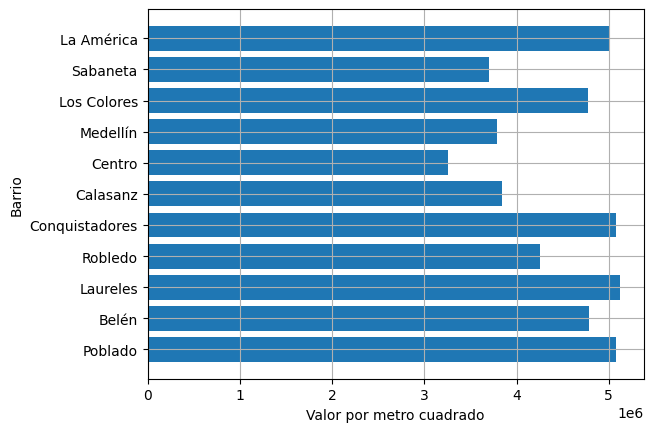

In [ ]:
#Pero si queremos hacer esto para todos los barrios disponibles, podemos hacer un ciclo, guardando los valores.
barrio=[]
precioPromedio=[]
#Creamos unas listas vacías.

for ba in data['Barrio'].unique():
  data2=data[data['Barrio']==ba]
  barrio.append(ba)
  precioPromedio.append(data2['ValorPorMetroCuadrado'].mean())

plt.barh(barrio, precioPromedio)
plt.xlabel('Valor por metro cuadrado')
plt.ylabel('Barrio')
plt.grid()

In [ ]:
data.groupby(by='Barrio').agg({'ValorPorMetroCuadrado':['mean','max','min']})


ValorPorMetroCuadrado                            
                                mean           max           min
Barrio                                                          
Belén                   4.787698e+06  5.968750e+06  3.650794e+06
Calasanz                3.846154e+06  3.846154e+06  3.846154e+06
Centro                  3.258427e+06  3.258427e+06  3.258427e+06
Conquistadores          5.081280e+06  5.597938e+06  4.745902e+06
La América              5.000000e+06  5.000000e+06  5.000000e+06
Laureles                5.120296e+06  6.167883e+06  4.380952e+06
Los Colores             4.776119e+06  4.776119e+06  4.776119e+06
Medellín                3.793103e+06  3.793103e+06  3.793103e+06
Poblado                 5.073028e+06  8.181818e+06  2.786885e+06
Robledo                 4.258751e+06  5.118421e+06  3.200000e+06
Sabaneta                3.698387e+06  3.701613e+06  3.695161e+06

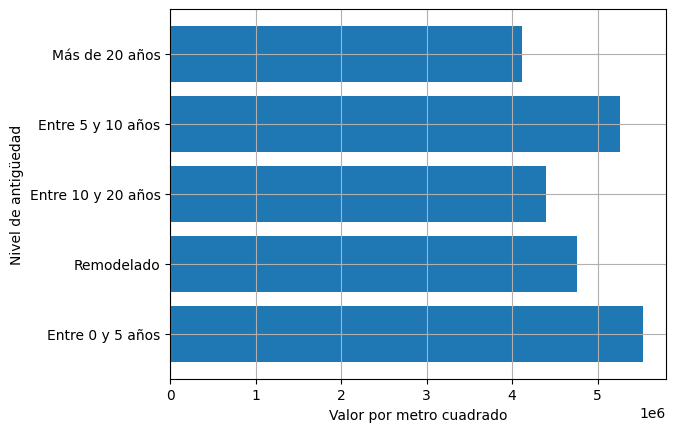

In [ ]:
#Pero si queremos hacer esto para todos los barrios disponibles, podemos hacer un ciclo, guardando los valores.
antiguedad=[]
precioPromedio=[]
for ant in data['Antiguedad'].unique():
  data2=data[data['Antiguedad']==ant]
  antiguedad.append(ant)
  precioPromedio.append(data2['ValorPorMetroCuadrado'].mean())

plt.barh(antiguedad, precioPromedio)
plt.xlabel('Valor por metro cuadrado')
plt.ylabel('Nivel de antigüedad')
plt.grid()